In [1]:
import time
import pandas as pd
import seaborn as sns
import os
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("src"))
from transform_before import transform_before
from transform_after import transform_after
from load import load_data
RESULTS_DIR = "results"


In [3]:
# --------------------------
# Step 1: Run pipeline BEFORE & AFTER
# --------------------------


RAW_PATH = "data/raw/yellow_tripdata_2016-01.csv"
PROCESSED_BEFORE = "data/processed/yellow_tripdata_2016_before.csv"
PROCESSED_AFTER = "data/processed/yellow_tripdata_2016_after.csv"

# Measure BEFORE transformation
start_before = time.time()
df_before = transform_before(RAW_PATH)
end_before = time.time()
time_before = end_before - start_before

# Save BEFORE CSV
load_data(df_before, PROCESSED_BEFORE)
print(f"⏱️ Execution time BEFORE: {time_before:.2f} sec")

# Measure AFTER transformation
start_after = time.time()
df_after = transform_after(RAW_PATH)
end_after = time.time()
time_after = end_after - start_after

# Save AFTER CSV
load_data(df_after, PROCESSED_AFTER)
print(f"⏱️ Execution time AFTER: {time_after:.2f} sec")

# --------------------------
# Step 2: Compute Metrics + Execution Time Improvement
# --------------------------

# Ensure trip durations are in minutes for comparison
df_before['trip_minutes'] = df_before['trip_minutes']  # already in minutes
df_after['trip_minutes'] = df_after['trip_duration'] / 60  # convert seconds → minutes

metrics = {
    'Total Trips': [len(df_before), len(df_after)],
    'Average Trip Duration (min)': [df_before['trip_minutes'].mean(), df_after['trip_minutes'].mean()],
    'Average Trip Distance (miles)': [df_before['trip_distance'].mean(), df_after['trip_distance'].mean()],
    'Average Fare Amount ($)': [df_before['fare_amount'].mean(), df_after['fare_amount'].mean()],
    'Transformation Time (sec)': [time_before, time_after]
}

metrics_df = pd.DataFrame(metrics, index=['BEFORE', 'AFTER'])

# Calculate execution time improvement
improvement_pct = ((time_before - time_after) / time_before) * 100
print(f"\n⏱️ Execution time improvement: {improvement_pct:.2f}%\n")

metrics_df

✅ Data saved to data/processed/yellow_tripdata_2016_before.csv
⏱️ Execution time BEFORE: 1030.34 sec
✅ Data saved to data/processed/yellow_tripdata_2016_after.csv
⏱️ Execution time AFTER: 190.80 sec

⏱️ Execution time improvement: 81.48%



,Total Trips,Average Trip Duration (min),Average Trip Distance (miles),Average Fare Amount ($),Transformation Time (sec)
BEFORE,10906858,15.268814,4.648197,12.486929,1030.340477
AFTER,10837127,0.255674,4.676160,12.445533,190.804936


In [19]:
# --------------------------
# Step 2: Compute Metrics + Execution Time Improvement
# --------------------------

metrics = {
    'Total Trips': [len(df_before), len(df_after)],
    'Average Trip Duration (min)': [df_before['trip_minutes'].mean(), df_after['trip_duration'].mean()],
    'Average Trip Distance (miles)': [df_before['trip_distance'].mean(), df_after['trip_distance'].mean()],
    'Average Fare Amount ($)': [df_before['fare_amount'].mean(), df_after['fare_amount'].mean()],
    'Execution Time (sec)': [end_before - start_before, end_after - start_after]
}

metrics_df = pd.DataFrame(metrics, index=['BEFORE', 'AFTER'])

# Calculate execution time improvement
exec_time_before = metrics_df.loc['BEFORE', 'Execution Time (sec)']
exec_time_after = metrics_df.loc['AFTER', 'Execution Time (sec)']
improvement_pct = ((exec_time_before - exec_time_after) / exec_time_before) * 100

print(f"⏱️ Execution time improvement: {improvement_pct:.2f}%\n")

metrics_df

⏱️ Execution time improvement: -37.19%



,Total Trips,Average Trip Duration (min),Average Trip Distance (miles),Average Fare Amount ($),Execution Time (sec)
BEFORE,83691,24.438299,194.354699,20.388305,1.613650
AFTER,79977,24.549538,203.352026,20.548581,2.213775


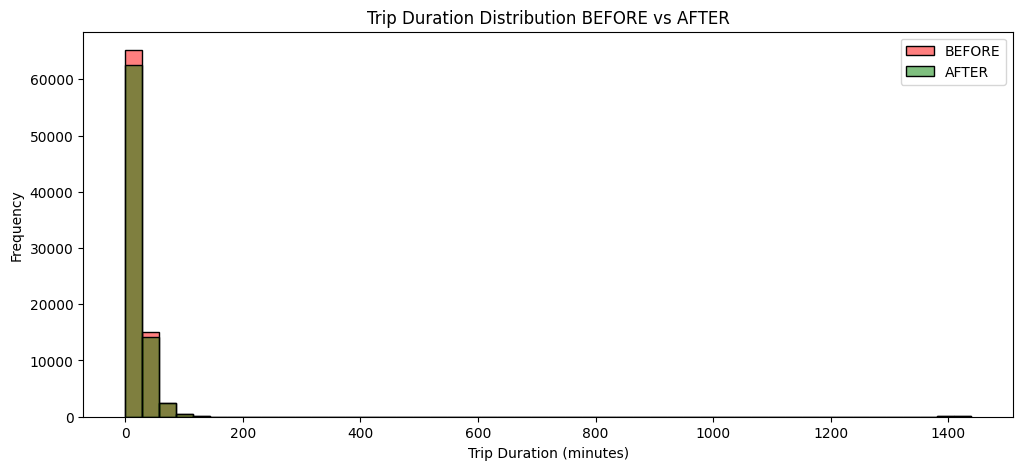

C:\Users\AHLEM\AppData\Local\Temp\ipykernel_14680\1888092420.py:19: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[df_before['fare_amount'], df_after['fare_amount']], palette=['red','green'])


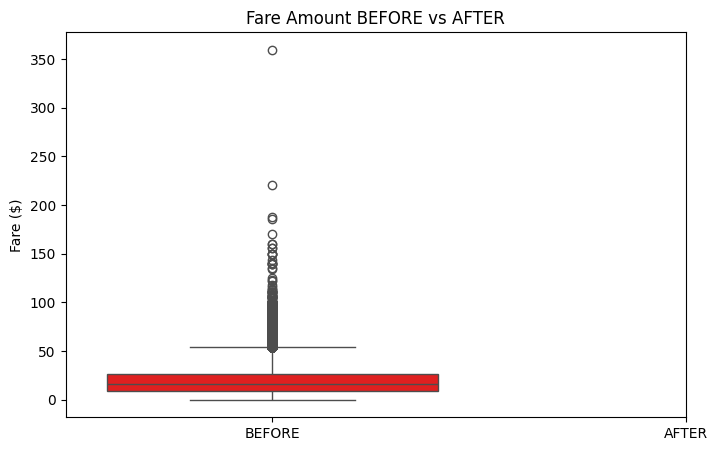

In [15]:
# --------------------------
# Step 3: Plot Metrics Comparisons
# --------------------------

# Trip Duration Histogram
plt.figure(figsize=(12,5))
sns.histplot(df_before['trip_minutes'], color='red', label='BEFORE', bins=50, alpha=0.5)
sns.histplot(df_after['trip_duration'], color='green', label='AFTER', bins=50, alpha=0.5)
plt.title("Trip Duration Distribution BEFORE vs AFTER")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Frequency")
plt.legend()
trip_duration_plot = os.path.join(RESULTS_DIR, "trip_duration_comparison.png")
plt.savefig(trip_duration_plot)
plt.show()

# Fare Amount Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=[df_before['fare_amount'], df_after['fare_amount']], palette=['red','green'])
plt.xticks([0,1], ['BEFORE','AFTER'])
plt.title("Fare Amount BEFORE vs AFTER")
plt.ylabel("Fare ($)")
fare_amount_plot = os.path.join(RESULTS_DIR, "fare_amount_comparison.png")
plt.savefig(fare_amount_plot)
plt.show()

c:\Users\AHLEM\Desktop\Optimizing NYC Taxi Data Pipeline with Lean Six Sigma\src\transform_before.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  """


✅ Data saved to c:\Users\AHLEM\Desktop\Optimizing NYC Taxi Data Pipeline with Lean Six Sigma\data\processed\before.csv
⏱️ Execution time BEFORE (transformation only): 0.34 sec
✅ Data saved to c:\Users\AHLEM\Desktop\Optimizing NYC Taxi Data Pipeline with Lean Six Sigma\data\processed\after.csv
⏱️ Execution time AFTER (transformation only): 0.76 sec

📊 Metrics Comparison:


,Total Trips,Average Trip Duration (min),Average Trip Distance (miles),Average Fare Amount ($),Transformation Time (sec)
BEFORE,83691,24.438299,194.354699,20.388305,0.335937
AFTER,79977,24.549538,203.352026,20.548581,0.763217



⏱️ Execution time improvement: -127.19%


In [20]:
# --------------------------
# Step 5: Generate PDF Report
# --------------------------
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors

pdf_path = os.path.join(RESULTS_DIR, "NYC_Taxi_LSS_Report.pdf")
doc = SimpleDocTemplate(pdf_path, pagesize=letter)
styles = getSampleStyleSheet()
elements = []

# Title
elements.append(Paragraph("NYC Taxi Data Pipeline Optimization Report", styles['Title']))
elements.append(Spacer(1, 12))

# Metrics Table
elements.append(Paragraph("📊 Metrics Comparison (BEFORE vs AFTER)", styles['Heading2']))
data_table = [ ["Metric", "BEFORE", "AFTER"] ]
for col in metrics_df.columns:
    data_table.append([col, f"{metrics_df[col]['BEFORE']:.2f}", f"{metrics_df[col]['AFTER']:.2f}"])

table = Table(data_table, hAlign='LEFT')
table.setStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
    ('GRID', (0,0), (-1,-1), 1, colors.black),
    ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold')
])
elements.append(table)
elements.append(Spacer(1, 12))

# Add Plots
elements.append(Paragraph("📈 Trip Duration Distribution", styles['Heading2']))
elements.append(Image(trip_duration_plot, width=480, height=240))
elements.append(Spacer(1,12))

elements.append(Paragraph("📈 Fare Amount Distribution", styles['Heading2']))
elements.append(Image(fare_amount_plot, width=480, height=240))
elements.append(Spacer(1,12))

# Build PDF
doc.build(elements)
print(f"✅ PDF report saved to {pdf_path}")

✅ PDF report saved to c:\Users\AHLEM\Desktop\Optimizing NYC Taxi Data Pipeline with Lean Six Sigma\results\NYC_Taxi_LSS_Report.pdf
